In [119]:
!pip install pandas numpy matplotlib seaborn spacy scikit-learn 
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [120]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [62]:
data = pd.read_csv('twitter_training.csv', header=None, names=['id','region','Sentiment','Text'])
data.head(30)

,id,region,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


In [63]:
data = data.drop(columns=["id", "region"])
data

,Sentiment,Text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...
...,...,...
74677,Positive,Just realized that the Windows partition of my...
74678,Positive,Just realized that my Mac window partition is ...
74679,Positive,Just realized the windows partition of my Mac ...
74680,Positive,Just realized between the windows partition of...


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  74682 non-null  object
 1   Text       73996 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [65]:
data.isnull().sum()

Sentiment      0
Text         686
dtype: int64

In [66]:
data = data.dropna()

In [67]:
data.isnull().sum()

Sentiment    0
Text         0
dtype: int64

In [ ]:
data.info()
data.head()

In [115]:
nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_punct or token.is_stop:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)
        
data.loc[:, "Text"] = data["Text"].apply(preprocess_text)

    

In [79]:
data.head(10)

,Sentiment,Text
0,Positive,m borderland murder
1,Positive,come border kill
2,Positive,m borderland kill
3,Positive,m come borderland murder
4,Positive,m borderland 2 murder
5,Positive,m borderland murder
6,Positive,spend hour fun know HUGE @borderlands fan Maya...
7,Positive,spend couple hour fun know huge Borderlands fa...
8,Positive,spend hour fun know HUGE Borderlands fan Maya ...
9,Positive,spend hour fun know HUGE RhandlerR fan Maya fa...


In [89]:
clf = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('logistic_regression', LogisticRegression(max_iter=200))
])

X = data.Text
y = data.Sentiment

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
report = classification_report(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.83      0.67      0.74      2578
    Negative       0.79      0.84      0.81      4537
     Neutral       0.81      0.73      0.77      3622
    Positive       0.73      0.83      0.78      4063

    accuracy                           0.78     14800
   macro avg       0.79      0.77      0.78     14800
weighted avg       0.79      0.78      0.78     14800



In [90]:
clf = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('naive_bayes', MultinomialNB())
])

X = data.Text
y = data.Sentiment

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
report = classification_report(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.94      0.45      0.61      2552
    Negative       0.66      0.90      0.76      4470
     Neutral       0.84      0.64      0.73      3611
    Positive       0.71      0.80      0.76      4167

    accuracy                           0.73     14800
   macro avg       0.79      0.70      0.71     14800
weighted avg       0.77      0.73      0.73     14800



In [91]:
clf = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('random_forest', RandomForestClassifier())
])

X = data.Text
y = data.Sentiment

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
report = classification_report(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.95      0.85      0.90      2476
    Negative       0.92      0.93      0.93      4549
     Neutral       0.95      0.89      0.92      3614
    Positive       0.85      0.94      0.90      4161

    accuracy                           0.91     14800
   macro avg       0.92      0.90      0.91     14800
weighted avg       0.91      0.91      0.91     14800



In [111]:
clf = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('k_neighbors', KNeighborsClassifier())
])

X = data.Text
y = data.Sentiment

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.91      0.87      0.89      2562
    Negative       0.90      0.90      0.90      4450
     Neutral       0.83      0.92      0.87      3658
    Positive       0.92      0.86      0.89      4130

    accuracy                           0.89     14800
   macro avg       0.89      0.89      0.89     14800
weighted avg       0.89      0.89      0.89     14800



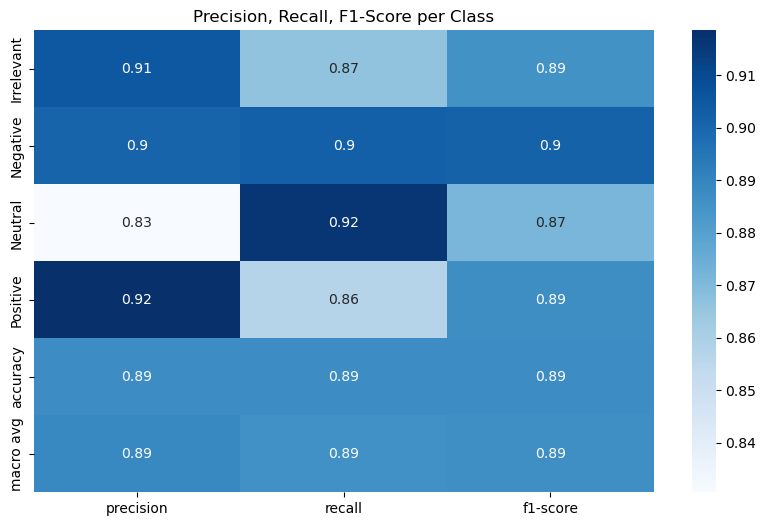

In [114]:
report = classification_report(y_test,y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_classes = df_report.iloc[:6][['precision', 'recall' , 'f1-score']]
plt.figure(figsize=(10, 6))
sns.heatmap(df_classes, annot=True, cmap='Blues')
plt.title('Precision, Recall, F1-Score per Class')
plt.show()

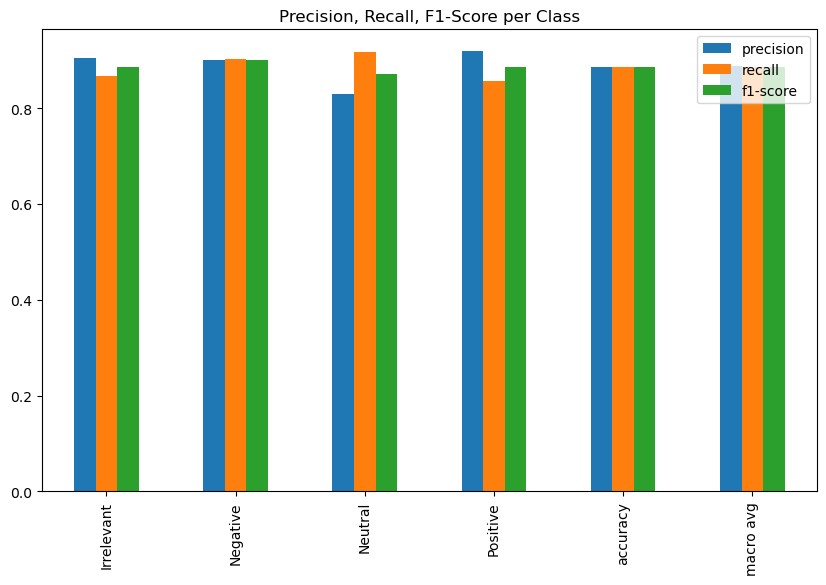

In [118]:
df_classes.plot(kind='bar', figsize=(10,6))
plt.title('Precision, Recall, F1-Score per Class')
plt.show()